# Data Wrangling, Feature Engineering, dan EDA
# Acne Severity Classification Dataset

Notebook ini digunakan untuk mengolah keseluruhan dataset gambar jerawat mulai dari import data, wrangling, feature engineering, EDA, quality checking, hingga export metadata akhir.

Dataset memiliki struktur:
- Folder **JPEGImages** berisi seluruh gambar.
- File **TXT** berisi daftar nama gambar berdasarkan level jerawat.

Tahapan yang dilakukan:
1. Import dataset lokal
2. Data Understanding
3. Gathering data dari file TXT.
4. Assessing data.
5. Cleaning data.
6. Feature engineering.
7. Exploratory Data Analysis.
8. Quality checking.
9. Export metadata akhir.

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

# 2. Data Understanding


**2.1 Menentukan Lokasi Dataset**

Pada tahap ini, path dataset ditentukan terlebih dahulu. Folder Classification berisi file TXT sebagai sumber label dan folder JPEGImages sebagai tempat semua gambar disimpan.

Kode di bawah ini untuk proses ketika menggunakan notebook

In [ ]:
data_path = "/content/drive/MyDrive/Coding Camp/CAPSTONE PROJECT/Dataset /Dataset Klasifikasi Jerawat/Classification"
image_dir = os.path.join(data_path, "JPEGImages")

txt_files = [
    "NNEW_trainval_0.txt",
    "NNEW_trainval_1.txt",
    "NNEW_trainval_2.txt",
    "NNEW_trainval_3.txt",
    "NNEW_trainval_4.txt",
    "NNEW_test_0.txt",
    "NNEW_test_1.txt",
    "NNEW_test_2.txt",
    "NNEW_test_3.txt",
    "NNEW_test_4.txt"
]

In [ ]:
! pwd

/content


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

Kode di bawah ini ketika menggunakan VSCODE 

In [2]:
data_path = "../data/Acnedataset"
image_dir = "../data/Acnedataset/JPEGImages"

txt_files = [
    "NNEW_trainval_0.txt",
    "NNEW_trainval_1.txt",
    "NNEW_trainval_2.txt",
    "NNEW_trainval_3.txt",
    "NNEW_trainval_4.txt",
    "NNEW_test_0.txt",
    "NNEW_test_1.txt",
    "NNEW_test_2.txt",
    "NNEW_test_3.txt",
    "NNEW_test_4.txt"
]

In [4]:
print("Isi folder Classification:")
print(os.listdir(data_path))

print("\nJumlah gambar di folder JPEGImages:")
print(len(os.listdir(image_dir)))

Isi folder Classification:
['JPEGImages', 'NNEW_test_0.txt', 'NNEW_test_1.txt', 'NNEW_test_2.txt', 'NNEW_test_3.txt', 'NNEW_test_4.txt', 'NNEW_trainval_0.txt', 'NNEW_trainval_1.txt', 'NNEW_trainval_2.txt', 'NNEW_trainval_3.txt', 'NNEW_trainval_4.txt']

Jumlah gambar di folder JPEGImages:
1457


# 3. Gathering Data

Pada tahap ini, file TXT dibaca untuk mengambil daftar gambar berdasarkan level jerawat.

Dataset ini tidak menggunakan folder kelas secara langsung. Label kelas disimpan pada file TXT, sehingga kita perlu membaca file TXT dan mengubahnya menjadi dataframe.


**3.1 Membaca File TXT dan Membuat Dataframe**

Dataset ini tidak menggunakan folder kelas secara langsung. Label tingkat keparahan jerawat disimpan pada file TXT.

Pada tahap ini akan dilakukan:
- membaca file TXT,
- mengambil nama gambar,
- membuat filepath,
- memberi label level,
- menentukan split data.


In [12]:
import re

data = []

for level in range(4):
    for split in ["trainval", "test"]:

        txt_path = os.path.join(data_path, f"NNEW_{split}_{level}.txt")

        if os.path.exists(txt_path):
            with open(txt_path, "r") as file:
                daftar = file.read().splitlines()

            for baris in daftar:
                bagian = baris.split()
                nama_gambar = bagian[0]

                # ambil level dari nama file, contoh: levle0_451.jpg
                match = re.search(r"levle(\d+)_", nama_gambar)
                label = int(match.group(1)) if match else level

                data.append({
                    "filename": nama_gambar,
                    "filepath": os.path.join(image_dir, nama_gambar),
                    "level": label,
                    "split": split
                })

df = pd.DataFrame(data)

print(df.head())

         filename                                       filepath  level  \
0    levle0_0.jpg    ../data/Acnedataset/JPEGImages\levle0_0.jpg      0   
1    levle0_1.jpg    ../data/Acnedataset/JPEGImages\levle0_1.jpg      0   
2  levle0_100.jpg  ../data/Acnedataset/JPEGImages\levle0_100.jpg      0   
3  levle0_101.jpg  ../data/Acnedataset/JPEGImages\levle0_101.jpg      0   
4  levle0_102.jpg  ../data/Acnedataset/JPEGImages\levle0_102.jpg      0   

      split  
0  trainval  
1  trainval  
2  trainval  
3  trainval  
4  trainval  


📌 **Insight**

Data dari seluruh file TXT berhasil dikumpulkan menjadi dataframe.

Kolom yang terbentuk:
- **filename**: nama file gambar.
- **filepath**: lokasi lengkap gambar.
- **level**: tingkat keparahan jerawat.
- **split**: pembagian trainval atau test.

**3.2 Mengecek Jumlah Data yang Berhasil Dikumpulkan**

Pada tahap ini, jumlah data dicek untuk memastikan semua file TXT sudah berhasil dibaca dan digabungkan ke dalam dataframe.

In [13]:
print("Jumlah total data:", len(df))
print("Jumlah kolom:", df.shape[1])

df.info()

Jumlah total data: 5828
Jumlah kolom: 4
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5828 entries, 0 to 5827
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  5828 non-null   object
 1   filepath  5828 non-null   object
 2   level     5828 non-null   int64 
 3   split     5828 non-null   object
dtypes: int64(1), object(3)
memory usage: 182.3+ KB


# 4. Assessing Data

Tahap mengecek kondisi awal data. Di sini kamu mencari masalah seperti data kosong, duplikat, file gambar tidak ditemukan, label tidak sesuai, atau struktur data belum rapi.

**4.1 Cek Missing Value**

Missing value dicek untuk mengetahui apakah ada data kosong pada kolom penting seperti filename, filepath, level, dan split.

In [14]:
df.isnull().sum()

filename    0
filepath    0
level       0
split       0
dtype: int64

📌 **Insight**

Tidak ada data kosong pada metadata awal

**4.2 Cek Data Duplikat**

Data duplikat perlu dicek agar satu gambar tidak dihitung lebih dari satu kali.


In [15]:
jumlah_duplikat = df.duplicated().sum()

print("Jumlah data duplikat:", jumlah_duplikat)

df[df.duplicated()].head()

Jumlah data duplikat: 3203


,filename,filepath,level,split
1457,levle0_0.jpg,../data/Acnedataset/JPEGImages\levle0_0.jpg,0,trainval
1458,levle0_1.jpg,../data/Acnedataset/JPEGImages\levle0_1.jpg,0,trainval
1459,levle0_100.jpg,../data/Acnedataset/JPEGImages\levle0_100.jpg,0,trainval
1460,levle0_101.jpg,../data/Acnedataset/JPEGImages\levle0_101.jpg,0,trainval
1461,levle0_102.jpg,../data/Acnedataset/JPEGImages\levle0_102.jpg,0,trainval


**Insight**

Berdasarkan hasil pengecekan, ditemukan sebanyak **3.203 data duplikat** pada dataframe. Hal ini menunjukkan bahwa terdapat banyak baris data yang memiliki informasi sama, seperti `filename`, `filepath`, `level`, dan `split`. Duplikasi data perlu diperhatikan karena dapat menyebabkan satu gambar dihitung lebih dari satu kali dalam proses analisis.

Namun, pengecekan ini baru mendeteksi duplikasi baris yang sama persis. Untuk memastikan tidak terjadi data leakage antara data training dan testing, perlu dilakukan pengecekan tambahan menggunakan. 



In [16]:
df_train = df[df["split"] == "trainval"].copy()
df_test = df[df["split"] == "test"].copy()

print("Duplikat baris train:", df_train.duplicated().sum())
print("Duplikat baris test:", df_test.duplicated().sum())

print("Duplikat filename train:", df_train["filename"].duplicated().sum())
print("Duplikat filename test:", df_test["filename"].duplicated().sum())

same_filename = set(df_train["filename"]).intersection(set(df_test["filename"]))
print("File yang muncul di train dan test:", len(same_filename))

Duplikat baris train: 3203
Duplikat baris test: 0
Duplikat filename train: 3203
Duplikat filename test: 0
File yang muncul di train dan test: 1168


📌 **Insight:**

Berdasarkan hasil pengecekan, ditemukan **3.203 duplikat baris dan file name** pada data `trainval`, sedangkan pada data `test` tidak ditemukan duplikasi. Hal ini menunjukkan bahwa masalah duplikasi paling banyak terjadi pada data training.

Namun, hasil yang paling penting adalah terdapat **1.168 file yang muncul di train dan test**. Kondisi ini menunjukkan adanya potensi **data leakage**, karena gambar yang sama atau memiliki nama file yang sama muncul pada dua subset berbeda.

Data perlu dibersihkan dengan menghapus duplikasi dan memastikan tidak ada file yang sama muncul pada train dan test. 


**4.3 Cek duplikasi  File gambar  dan gambar yang tidak dapat ditemukan**

Tahap ini digunakan untuk memastikan semua gambar yang tertulis pada file TXT benar benar tersedia di Folder Images

In [17]:
import hashlib

# =====================================================================
# PERBAIKAN: Definisikan df_train dan df_test terlebih dahulu dari 'df'
# =====================================================================
df_train = df[df["split"] == "trainval"].copy()
df_test = df[df["split"] == "test"].copy()


# Fungsi untuk mengambil MD5 hash dari file gambar
def get_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()


# Menerapkan fungsi hash pada kolom filepath
df_train["image_hash"] = df_train["filepath"].apply(get_hash)
df_test["image_hash"] = df_test["filepath"].apply(get_hash)

# Menghitung duplikat internal
print("Duplikat gambar train:", df_train["image_hash"].duplicated().sum())
print("Duplikat gambar test:", df_test["image_hash"].duplicated().sum())

# Menghitung kebocoran data (data leakage) antara train dan test
same_image = set(df_train["image_hash"]).intersection(set(df_test["image_hash"]))
print("Gambar sama di train dan test:", len(same_image))

Duplikat gambar train: 3241
Duplikat gambar test: 25
Gambar sama di train dan test: 1143


In [18]:
df["file_exists"] = df["filepath"].apply(os.path.exists)

print("Jumlah gambar tersedia:", df["file_exists"].sum())
print("Jumlah gambar tidak ditemukan:", (~df["file_exists"]).sum())

df[df["file_exists"] == False].head()

Jumlah gambar tersedia: 5828
Jumlah gambar tidak ditemukan: 0


,filename,filepath,level,split,file_exists


**Insight**

Berdasarkan hasil pengecekan menggunakan **MD5 hash**, ditemukan **3.241 duplikat gambar pada data train**, **25 duplikat gambar pada data test**, dan **1.143 gambar yang sama muncul pada train dan test**. Hasil ini menunjukkan bahwa terdapat masalah duplikasi gambar dan potensi **data leakage** pada pembagian dataset awal.

Pengecekan menggunakan `image_hash` lebih kuat dibandingkan hanya menggunakan `filename`, karena hash memeriksa isi file gambar secara langsung. 

Dataset perlu dibersihkan terlebih dahulu dengan menghapus gambar duplikat dan memastikan tidak ada `image_hash` yang sama muncul pada train dan test. Setelah itu, pembagian data perlu dilakukan ulang menggunakan data unik agar proses training dan evaluasi model lebih adil serta bebas dari data leakage.


**4.4 Cek Distribusi Level Awal**

Pada tahap ini dilakukan analisis distribusi jumlah data pada setiap level jerawat untuk mengetahui apakah dataset memiliki keseimbangan jumlah sampel (balanced dataset) atau tidak.

Distribusi label penting diperiksa karena dapat memengaruhi performa model klasifikasi. Dataset yang terlalu tidak seimbang (imbalanced) dapat menyebabkan model lebih sering memprediksi kelas yang memiliki jumlah data lebih banyak.

Analisis dilakukan menggunakan kolom `level` yang telah dibuat dari proses pembacaan file anotasi (`NNEW_trainval_x.txt` dan `NNEW_test_x.txt`).


In [20]:
print("Total data:", len(df))

print("\nDistribusi level:")
print(df["level"].value_counts().sort_index())

print("\nDistribusi split:")
print(df["split"].value_counts())

print("\nCek data per split dan level:")
print(pd.crosstab(df["split"], df["level"]))

Total data: 5828

Distribusi level:
level
0    1988
1    2548
2     744
3     548
Name: count, dtype: int64

Distribusi split:
split
trainval    4660
test        1168
Name: count, dtype: int64

Cek data per split dan level:
level        0     1    2    3
split                         
test       400   512  147  109
trainval  1588  2036  597  439


**Insight:**

Berdasarkan hasil pengecekan, total data awal berjumlah **5.828 sampel** dengan pembagian **4.660 data trainval** dan **1.168 data test**. Pembagian ini secara jumlah sudah mendekati rasio **80:20**. Distribusi level juga terlihat tetap terbagi pada setiap split, yaitu level 0, 1, 2, dan 3. Namun, data masih menunjukkan ketidakseimbangan kelas, karena level 1 memiliki jumlah data paling banyak, sedangkan level 3 memiliki jumlah data paling sedikit.


4.5 Cek data leakage


In [21]:

leak_train = df_train[df_train["image_hash"].isin(same_image)].copy()
leak_test = df_test[df_test["image_hash"].isin(same_image)].copy()

print("Leakage per label di data test:")
display(leak_test["level"].value_counts().sort_index())

print("Leakage per label di data train:")
display(leak_train["level"].value_counts().sort_index())

print(df_train.columns)


Leakage per label di data test:


level
0    400
1    512
2    147
3    109
Name: count, dtype: int64

Leakage per label di data train:


level
0    1220
1    1556
2     449
3     327
Name: count, dtype: int64

Index(['filename', 'filepath', 'level', 'split', 'image_hash'], dtype='object')


**Insight:**

Hasil pengecekan data leakage menunjukkan masalah yang serius. Pada data test, seluruh sampel terdeteksi sebagai leakage, yaitu **400 sampel level 0, 512 sampel level 1, 147 sampel level 2, dan 109 sampel level 3**. Jumlah ini sama dengan total data test, yaitu **1.168 sampel**. Artinya, semua gambar pada data test memiliki `image_hash` yang juga muncul pada data train.



# 5. Cleaning / Validasi Data

Pada tahap ini, cleaning tidak dilakukan dengan menghapus file gambar secara langsung dari folder dataset. Cleaning dilakukan pada metadata/DataFrame agar data yang digunakan untuk analisis dan pelatihan lebih bersih. Berdasarkan hasil assessing, ditemukan adanya data duplikat pada data train, sehingga dilakukan penghapusan baris duplikat pada data train.

Selain itu, validasi juga dilakukan untuk memastikan struktur data sudah benar, label terbaca dengan tepat, file gambar tersedia, tidak ada missing value, serta tidak terdapat file gambar yang corrupt atau tidak dapat dibuka.

In [22]:
jumlah_awal = len(df_train)

df_train = df_train.drop_duplicates()

jumlah_akhir = len(df_train)

print("Data train sebelum:", jumlah_awal)
print("Data train sesudah:", jumlah_akhir)
print("Data train terhapus:", jumlah_awal - jumlah_akhir)

Data train sebelum: 4660
Data train sesudah: 1457
Data train terhapus: 3203


📌 **Insight**

Berdasarkan hasil pengecekan dan penghapusan duplikasi, jumlah data train berkurang dari 4660 menjadi 1457 data. Sebanyak 3203 data terhapus karena memiliki nilai baris yang sama. Hal ini menunjukkan bahwa data train sebelumnya mengandung duplikasi yang cukup tinggi, yaitu sekitar 68,7%. Penghapusan duplikat ini penting agar proses analisis dan pelatihan model tidak bias akibat gambar atau metadata yang tercatat berulang.

**5.1 Cek Gambar Corrupt**

Tahap ini memastikan apakah ada beberapa gambar yang tidak bisa dibuka

In [23]:
from PIL import Image

def check_corrupt(filepath):
    try:
        img = Image.open(filepath)
        img.verify()
        return False

    except:
        return True


df["is_corrupt"] = (
    df["filepath"]
    .apply(check_corrupt)
)

print(
    "Jumlah gambar corrupt:",
    df["is_corrupt"].sum()
)

Jumlah gambar corrupt: 0


**Insight:**

Berdasarkan hasil pengecekan, tidak ditemukan gambar corrupt pada dataset karena jumlah gambar corrupt adalah **0**. Hal ini menunjukkan bahwa seluruh file gambar pada dataframe masih dapat dibuka dan diverifikasi menggunakan library PIL.

Pengecekan ini penting karena gambar yang corrupt atau tidak dapat dibuka dapat menyebabkan error saat proses preprocessing, training model, atau evaluasi. Karena tidak ada gambar corrupt, dataset dapat dilanjutkan ke tahap analisis dan pemrosesan berikutnya tanpa perlu menghapus file berdasarkan kerusakan gambar.

Namun, pengecekan ini hanya memastikan bahwa file gambar dapat dibuka. Validasi kualitas gambar tetap perlu dilakukan melalui analisis lain seperti ukuran gambar, brightness, blur score, dan duplikasi gambar agar data yang digunakan benar-benar layak untuk pelatihan model.


**5.2 Split ulang setelah cleaning data**

In [40]:
from sklearn.model_selection import train_test_split

# Mengecek jumlah data sebelum pembagian ulang
print("Jumlah data sebelum cleaning:", len(df))
print("Jumlah filename unik:", df["filename"].nunique())

print("\nDistribusi level sebelum cleaning:")
print(df["level"].value_counts().sort_index())

#Menghapus duplikasi berdasarkan nama gambar
#Satu filename hanya boleh muncul satu kali agar tidak bocor ke train dan test
df_unique = (
    df
    .drop_duplicates(subset=["filename"])
    .reset_index(drop=True)
)

print("\nJumlah data setelah mengambil gambar unik:", len(df_unique))

print("\nDistribusi level setelah mengambil gambar unik:")
print(df_unique["level"].value_counts().sort_index())

#Membagi ulang data unik menjadi trainval dan test baru
train_metadata, test_metadata = train_test_split(
    df_unique,
    test_size=0.2,
    random_state=42,
    stratify=df_unique["level"]
)

# Memberi label split baru
train_metadata = train_metadata.copy()
test_metadata = test_metadata.copy()

train_metadata["split"] = "trainval"
test_metadata["split"] = "test"

# Menggabungkan kembali metadata
df_clean = pd.concat(
    [train_metadata, test_metadata],
    ignore_index=True
)

# Validasi hasil split baru
print("\nDistribusi split baru:")
print(df["split"].value_counts())

print("\nDistribusi level pada trainval:")
print(train_metadata["level"].value_counts().sort_index())

print("\nDistribusi level pada test:")
print(test_metadata["level"].value_counts().sort_index())

# Mengecek apakah masih ada gambar yang muncul di trainval dan test sekaligus
train_files = set(train_metadata["filename"])
test_files = set(test_metadata["filename"])

overlap = train_files.intersection(test_files)

print("\nJumlah filename yang overlap antara trainval dan test:", len(overlap))

Jumlah data sebelum cleaning: 5828
Jumlah filename unik: 1457

Distribusi level sebelum cleaning:
level
0    1988
1    2548
2     744
3     548
Name: count, dtype: int64

Jumlah data setelah mengambil gambar unik: 1457

Distribusi level setelah mengambil gambar unik:
level
0    497
1    637
2    186
3    137
Name: count, dtype: int64

Distribusi split baru:
split
trainval    4660
test        1168
Name: count, dtype: int64

Distribusi level pada trainval:
level
0    397
1    509
2    149
3    110
Name: count, dtype: int64

Distribusi level pada test:
level
0    100
1    128
2     37
3     27
Name: count, dtype: int64

Jumlah filename yang overlap antara trainval dan test: 0


**Insight:**

Berdasarkan hasil cleaning, jumlah data awal sebanyak **5.828 sampel** berkurang menjadi **1.457 sampel unik** setelah dilakukan penghapusan duplikasi berdasarkan `filename`. Hal ini menunjukkan bahwa terdapat banyak data berulang pada dataset awal, sehingga perlu dibersihkan agar satu gambar tidak dihitung lebih dari satu kali.

Setelah data unik diperoleh, dataset dibagi ulang menjadi data `trainval` dan `test` dengan rasio 80:20 menggunakan metode stratified split berdasarkan kolom `level`. Hasil pembagian baru menghasilkan **1.165 data trainval** dan **292 data test**. Penggunaan stratified split membantu menjaga agar setiap level jerawat tetap terwakili pada data trainval dan test.

Hasil validasi menunjukkan bahwa jumlah `filename` yang overlap antara trainval dan test adalah **0**. Artinya, berdasarkan nama file, tidak ada gambar yang sama muncul pada kedua subset. Hal ini penting untuk mencegah data leakage, karena data test harus benar-benar terpisah dari data training agar evaluasi model lebih valid.

Namun, karena pada tahap sebelumnya ditemukan adanya kesamaan gambar berdasarkan `image_hash`, validasi akhir sebaiknya juga dilakukan menggunakan `image_hash`, bukan hanya `filename`. Dengan begitu, dataset dapat dipastikan lebih aman dari kebocoran data baik berdasarkan nama file maupun isi gambar.


# 6. Feature Engineering

Tahap membuat fitur baru dari gambar. Di sini kita tidak mengubah isi gambar, tetapi mengambil informasi penting dari gambar, seperti ukuran, resolusi, brightness, dan blur score.

**6.1 Import Library Tambahan**

In [24]:
from PIL import Image
import cv2
import numpy as np
import os

**6.2 Membuat fungsi ekstraksi fitur gambar**

Fungsi ini digunakan untuk membaca setiap gambar dan mengambil fitur penting. Fitur yang diambil adalah ukuran gambar, channel warna, ukuran file, aspect ratio, total pixels, brightness, dan blur score.

Brightness dihitung dari rata-rata nilai pixel grayscale. Blur score dihitung menggunakan variance of Laplacian. Semakin kecil nilai blur score, semakin besar kemungkinan gambar tersebut blur.

In [25]:
def extract_image_features(filepath):
    try:
        #Membaca gambar menggunakan PIL
        image = Image.open(filepath).convert("RGB")

        #Mengambil ukuran gambar
        width, height = image.size

        #Mengambil jumlah channel warna
        channel = len(image.getbands())

        #Mengambil ukuran file dalam KB
        file_size_kb = os.path.getsize(filepath) / 1024

        # Menghitung aspect ratio
        aspect_ratio = width / height

        # Menghitung total pixels
        total_pixels = width * height

        # Membaca gambar menggunakan OpenCV
        image_cv = cv2.imread(filepath)

        #Mengubah gambar menjadi grayscale
        gray = cv2.cvtColor(image_cv, cv2.COLOR_BGR2GRAY)

        #Menghitung brightness
        brightness = np.mean(gray)

        #Menghitung blur score
        blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()

        return pd.Series({
            "width": width,
            "height": height,
            "channel": channel,
            "file_size_kb": round(file_size_kb, 2),
            "aspect_ratio": round(aspect_ratio, 4),
            "total_pixels": total_pixels,
            "brightness": round(brightness, 2),
            "blur_score": round(blur_score, 2)
        })

    except Exception as e:
        return pd.Series({
            "width": np.nan,
            "height": np.nan,
            "channel": np.nan,
            "file_size_kb": np.nan,
            "aspect_ratio": np.nan,
            "total_pixels": np.nan,
            "brightness": np.nan,
            "blur_score": np.nan
        })

**6.3 Menerapkan Fungsi ke keseluruhan dataset**

Fungsi ekstraksi fitur diterapkan ke semua gambar yang ada pada dataframe.

In [26]:
image_features = df["filepath"].apply(extract_image_features)

image_features.head()

,width,height,channel,file_size_kb,aspect_ratio,total_pixels,brightness,blur_score
0,525.0,700.0,3.0,48.00,0.7500,367500.0,107.39,439.83
1,3112.0,3456.0,3.0,827.53,0.9005,10755072.0,85.28,81.62
2,3112.0,3456.0,3.0,642.27,0.9005,10755072.0,81.70,40.81
3,3112.0,3456.0,3.0,881.05,0.9005,10755072.0,94.72,78.00
4,3112.0,3456.0,3.0,656.16,0.9005,10755072.0,81.50,27.97


**Insight:**

Fungsi ekstraksi fitur berhasil diterapkan ke seluruh gambar pada dataframe. Hasil output menunjukkan beberapa fitur penting dari gambar, yaitu `width`, `height`, `channel`, `file_size_kb`, `aspect_ratio`, `total_pixels`, `brightness`, dan `blur_score`.

Fitur-fitur tersebut digunakan untuk memahami karakteristik kualitas gambar dalam dataset. Misalnya, `width` dan `height` menunjukkan ukuran gambar, `channel` menunjukkan jumlah channel warna, `file_size_kb` menunjukkan ukuran file, sedangkan `brightness` dan `blur_score` membantu melihat tingkat kecerahan serta ketajaman gambar.
Hasil ini menunjukkan bahwa dataset memiliki variasi resolusi gambar, sehingga pada tahap pemodelan gambar perlu diproses ulang ke ukuran yang seragam agar dapat digunakan oleh model CNN.



**6.4 Menggabungkan Fitur dengan dataframe utama**

Setelah fitur gambar berhasil dibuat, hasilnya digabungkan dengan dataframe utama agar semua informasi berada dalam satu tabel.


In [27]:
df = pd.concat([df, image_features], axis=1)

df.head()

,filename,filepath,level,split,file_exists,is_corrupt,width,height,channel,file_size_kb,aspect_ratio,total_pixels,brightness,blur_score
0,levle0_0.jpg,../data/Acnedataset/JPEGImages\levle0_0.jpg,0,trainval,True,False,525.0,700.0,3.0,48.00,0.7500,367500.0,107.39,439.83
1,levle0_1.jpg,../data/Acnedataset/JPEGImages\levle0_1.jpg,0,trainval,True,False,3112.0,3456.0,3.0,827.53,0.9005,10755072.0,85.28,81.62
2,levle0_100.jpg,../data/Acnedataset/JPEGImages\levle0_100.jpg,0,trainval,True,False,3112.0,3456.0,3.0,642.27,0.9005,10755072.0,81.70,40.81
3,levle0_101.jpg,../data/Acnedataset/JPEGImages\levle0_101.jpg,0,trainval,True,False,3112.0,3456.0,3.0,881.05,0.9005,10755072.0,94.72,78.00
4,levle0_102.jpg,../data/Acnedataset/JPEGImages\levle0_102.jpg,0,trainval,True,False,3112.0,3456.0,3.0,656.16,0.9005,10755072.0,81.50,27.97


**Insight:**

Pada tahap ini, fitur hasil ekstraksi gambar berhasil digabungkan dengan dataframe utama. 
Penggabungan ini penting karena seluruh informasi gambar berada dalam satu dataframe, sehingga proses analisis menjadi lebih mudah. Data dapat digunakan untuk melihat kualitas gambar, mengecek ukuran file, mengetahui variasi resolusi gambar, serta menganalisis tingkat kecerahan dan ketajaman gambar pada setiap level jerawat.

Hasil awal menunjukkan bahwa file gambar dapat ditemukan dan tidak corrupt, karena kolom `file_exists` bernilai `True` dan `is_corrupt` bernilai `False` pada sampel yang ditampilkan. Selain itu, terlihat bahwa ukuran gambar berbeda-beda, sehingga pada tahap training model CNN gambar tetap perlu di-resize ke ukuran yang seragam.

Kolom `level` tetap digunakan sebagai target atau label kelas, sedangkan fitur seperti `width`, `height`, `brightness`, dan `blur_score` digunakan untuk analisis kualitas data. Jika data ini digunakan untuk training model, kolom seperti `level`, `filename`, `filepath`, dan `split` tidak boleh dimasukkan sebagai fitur input agar tidak terjadi data leakage.


**6.5 Cek Hasil feature engineering**

Tahap ini digunakan untuk memastikan semua fitur baru berhasil dibuat dan tidak ada nilai kosong yang muncul setelah ekstraksi fitur.

In [28]:
feature_columns = [
    "width",
    "height",
    "channel",
    "file_size_kb",
    "aspect_ratio",
    "total_pixels",
    "brightness",
    "blur_score"
]

df[feature_columns].head()

,width,height,channel,file_size_kb,aspect_ratio,total_pixels,brightness,blur_score
0,525.0,700.0,3.0,48.00,0.7500,367500.0,107.39,439.83
1,3112.0,3456.0,3.0,827.53,0.9005,10755072.0,85.28,81.62
2,3112.0,3456.0,3.0,642.27,0.9005,10755072.0,81.70,40.81
3,3112.0,3456.0,3.0,881.05,0.9005,10755072.0,94.72,78.00
4,3112.0,3456.0,3.0,656.16,0.9005,10755072.0,81.50,27.97


**Insight**

Hasil pengecekan menunjukkan bahwa proses feature engineering berhasil menghasilkan fitur baru, yaitu `width`, `height`, `channel`, `file_size_kb`, `aspect_ratio`, `total_pixels`, `brightness`, dan `blur_score`. Fitur-fitur tersebut sudah muncul dalam dataframe dan dapat digunakan untuk analisis kualitas gambar.

Dari sampel data yang ditampilkan, setiap gambar memiliki informasi ukuran, jumlah channel warna, ukuran file, rasio aspek, total piksel, tingkat kecerahan, dan tingkat ketajaman gambar. Hal ini menunjukkan bahwa fitur teknis gambar berhasil diekstraksi dengan baik.

Fitur `width`, `height`, `aspect_ratio`, dan `total_pixels` dapat membantu melihat variasi resolusi gambar. Fitur `brightness` digunakan untuk melihat tingkat kecerahan gambar, sedangkan `blur_score` digunakan untuk memperkirakan ketajaman gambar. Nilai `blur_score` yang rendah dapat menunjukkan gambar yang lebih buram, sedangkan nilai yang lebih tinggi menunjukkan gambar lebih tajam.

**6.6 Cek Missing Value Pada fitur baru**

Missing value pada fitur baru dicek untuk memastikan tidak ada gambar yang gagal diproses saat feature engineering.

In [29]:
df[feature_columns].isnull().sum()

width           0
height          0
channel         0
file_size_kb    0
aspect_ratio    0
total_pixels    0
brightness      0
blur_score      0
dtype: int64

**Insight:**

Berdasarkan hasil pengecekan missing value, seluruh fitur baru hasil feature engineering memiliki nilai **0 missing value**.Hal ini menunjukkan bahwa proses ekstraksi fitur berhasil dilakukan pada seluruh gambar dalam dataframe. Tidak ada gambar yang gagal diproses saat pembuatan fitur, sehingga fitur hasil ekstraksi dapat digunakan untuk tahap analisis lanjutan.

**6.7 Statistik Desk fitur Gambar**

Statistik deskriptif digunakan untuk melihat gambaran umum fitur gambar, seperti nilai minimum, maksimum, rata-rata, dan standar deviasi.

In [30]:
df[feature_columns].describe()

,width,height,channel,file_size_kb,aspect_ratio,total_pixels,brightness,blur_score
count,5828.000000,5828.000000,5828.0,5828.000000,5828.000000,5.828000e+03,5828.000000,5828.000000
mean,2918.286205,3027.748799,3.0,756.628085,0.966242,9.782844e+06,97.547001,109.039472
std,1112.585773,1002.478625,0.0,328.363424,0.212263,4.178080e+06,17.995419,206.416327
min,143.000000,155.000000,3.0,3.250000,0.562300,2.431000e+04,42.910000,3.940000
25%,3112.000000,3456.000000,3.0,679.990000,0.900500,1.075507e+07,86.710000,38.350000
50%,3112.000000,3456.000000,3.0,855.490000,0.900500,1.075507e+07,95.560000,74.950000
75%,3112.000000,3456.000000,3.0,962.800000,0.900500,1.075507e+07,104.850000,113.740000
max,5184.000000,3456.000000,3.0,1353.240000,1.778400,1.791590e+07,174.880000,3963.120000


**Insight:**

Berdasarkan statistik deskriptif fitur gambar, seluruh fitur memiliki jumlah data sebanyak **5.828 sampel**. Nilai ini menunjukkan bahwa fitur berhasil dihitung untuk seluruh data pada dataframe yang sedang digunakan. Namun, karena pada tahap cleaning sebelumnya jumlah data unik adalah **1.457 sampel**, maka output ini perlu diperiksa kembali untuk memastikan dataframe yang dianalisis sudah menggunakan data hasil cleaning, bukan dataframe awal yang masih mengandung duplikasi.


**6.8 Cek Sampel data setelah proses Feature Engineering**

Tahap ini digunakan untuk melihat beberapa baris data setelah fitur gambar ditambahkan.

In [31]:
df[
    [
        "filename",
        "split",
        "level",
        "width",
        "height",
        "channel",
        "file_size_kb",
        "aspect_ratio",
        "total_pixels",
        "brightness",
        "blur_score"
    ]
].head(10)

,filename,split,level,width,height,channel,file_size_kb,aspect_ratio,total_pixels,brightness,blur_score
0,levle0_0.jpg,trainval,0,525.0,700.0,3.0,48.00,0.7500,367500.0,107.39,439.83
1,levle0_1.jpg,trainval,0,3112.0,3456.0,3.0,827.53,0.9005,10755072.0,85.28,81.62
2,levle0_100.jpg,trainval,0,3112.0,3456.0,3.0,642.27,0.9005,10755072.0,81.70,40.81
3,levle0_101.jpg,trainval,0,3112.0,3456.0,3.0,881.05,0.9005,10755072.0,94.72,78.00
4,levle0_102.jpg,trainval,0,3112.0,3456.0,3.0,656.16,0.9005,10755072.0,81.50,27.97
5,levle0_104.jpg,trainval,0,3112.0,3456.0,3.0,979.73,0.9005,10755072.0,110.01,78.93
6,levle0_105.jpg,trainval,0,3112.0,3456.0,3.0,597.12,0.9005,10755072.0,73.49,22.87
7,levle0_106.jpg,trainval,0,3112.0,3456.0,3.0,828.40,0.9005,10755072.0,79.12,99.71
8,levle0_108.jpg,trainval,0,3112.0,3456.0,3.0,834.27,0.9005,10755072.0,101.83,70.64
9,levle0_109.jpg,trainval,0,3112.0,3456.0,3.0,805.69,0.9005,10755072.0,100.89,47.94


**Insight**

Hasil sampel data menunjukkan bahwa proses feature engineering berhasil menambahkan fitur baru ke dalam dataframe utama.
Dari 10 sampel awal yang ditampilkan, terlihat bahwa sebagian besar gambar memiliki ukuran **3112 × 3456 piksel** dengan 3 channel warna, sehingga gambar berada dalam format RGB. Namun, terdapat juga gambar dengan ukuran berbeda, seperti **525 × 700 piksel**. Hal ini menunjukkan bahwa resolusi gambar dalam dataset belum seragam.


# 7. Exploratory Data Analysis

Tahap “mengenali kondisi dataset” sebelum lanjut ke modeling, supaya kita tahu data bersih, seimbang, dan layak digunakan atau masih ada masalah.

In [42]:
df = df_clean.copy()

print("Jumlah data:", len(df))
print("Jumlah filename unik:", df["filename"].nunique())
print(df["level"].value_counts().sort_index())

Jumlah data: 1457
Jumlah filename unik: 1457
level
0    497
1    637
2    186
3    137
Name: count, dtype: int64


**Insight** 

Dilakukan validasi ulang terkait data untuk digunakan pada tahap EDA.
Hasil ini menunjukkan bahwa dataset final sudah lebih bersih dibandingkan data awal, tetapi masih memiliki ketidakseimbangan kelas. Level 1 menjadi kelas dengan jumlah data paling banyak, sedangkan level 3 menjadi kelas dengan jumlah data paling sedikit.

**7.1 Distribusi kelas**

Tahap ini digunakan untuk melihat jumlah gambar pada setiap level jerawat. Distribusi kelas penting untuk mengetahui apakah dataset seimbang atau terdapat level yang jumlahnya jauh lebih sedikit.

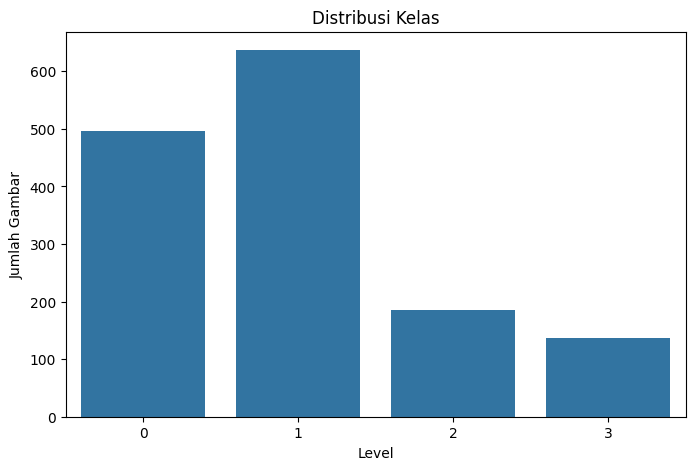

level
0    497
1    637
2    186
3    137
Name: count, dtype: int64

In [43]:
kelas = (
    df["level"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=kelas.index,
    y=kelas.values
)

plt.title("Distribusi Kelas")
plt.xlabel("Level")
plt.ylabel("Jumlah Gambar")

plt.show()

kelas

**Insight **

Grafik distribusi kelas menunjukkan bahwa data setelah cleaning masih didominasi oleh **level 1** dengan jumlah **637 gambar**, diikuti oleh **level 0** sebanyak **497 gambar**. Sementara itu, **level 2** hanya memiliki **186 gambar** dan **level 3** memiliki **137 gambar**.

Kondisi ini menunjukkan adanya **class imbalance** atau ketidakseimbangan kelas. Data untuk jerawat ringan dan normal lebih banyak dibandingkan data jerawat sedang dan berat. Hal ini penting diperhatikan karena model dapat lebih mudah mengenali kelas mayoritas, yaitu level 0 dan level 1, dibandingkan kelas minoritas seperti level 2 dan level 3.

Oleh karena itu, pada tahap evaluasi model, performa sebaiknya tidak hanya dilihat dari akurasi keseluruhan, tetapi juga dari metrik per kelas seperti precision, recall, dan confusion matrix.


**7.2 Persentase Kelas**

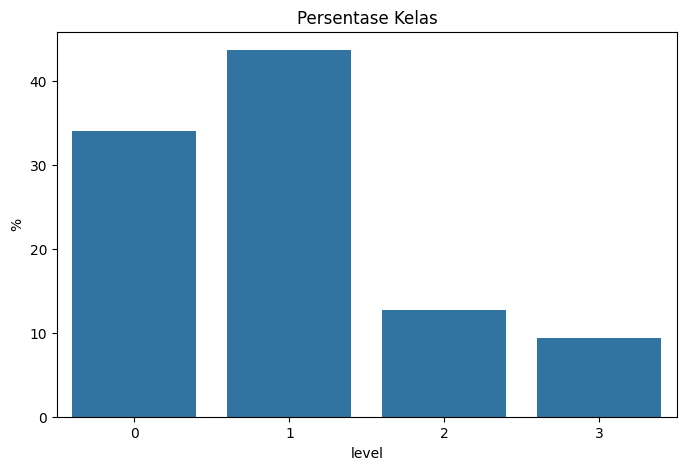

level
0    34.11
1    43.72
2    12.77
3     9.40
Name: proportion, dtype: float64

In [44]:
persen = (
    df["level"]
    .value_counts(normalize=True)
    .sort_index()
    *100
)

persen = persen.round(2)

plt.figure(figsize=(8,5))

sns.barplot(
    x=persen.index,
    y=persen.values
)

plt.title("Persentase Kelas")

plt.ylabel("%")

plt.show()

persen

** Insight**

Berdasarkan persentase kelas, **level 1** memiliki proporsi terbesar yaitu **43,72%**, kemudian **level 0** sebesar **34,11%**. Sementara itu, **level 2** hanya sebesar **12,77%** dan **level 3** sebesar **9,40%**.Lebih dari setengah data berada pada level 0 dan level 1, sedangkan level 2 dan level 3 memiliki proporsi yang jauh lebih kecil. 
Meskipun demikian, distribusi ini sudah lebih valid karena dihitung dari data yang telah dibersihkan dari duplikasi, sehingga hasil EDA lebih representatif dibandingkan analisis pada data awal.

**7.3 Distribusi Split Trainval dan Test**


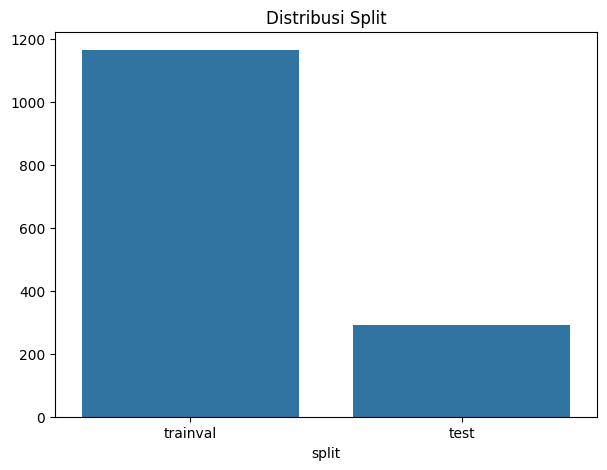

split
trainval    1165
test         292
Name: count, dtype: int64

In [45]:
split = (
    df["split"]
    .value_counts()
)

plt.figure(figsize=(7,5))

sns.barplot(
    x=split.index,
    y=split.values
)

plt.title("Distribusi Split")

plt.show()

split

**Insight** 

Grafik distribusi split menunjukkan bahwa data setelah cleaning dibagi menjadi **1.165 data trainval** dan **292 data test**. Pembagian ini mendekati rasio **80:20**, yaitu sekitar 80% untuk data training/validation dan 20% untuk data testing.Pembagian ini sudah sesuai untuk kebutuhan pemodelan karena sebagian besar data digunakan untuk melatih model, sedangkan sebagian kecil disimpan sebagai data uji. Data test berfungsi untuk mengevaluasi kemampuan model pada data yang tidak digunakan saat proses training.


**7.4 Distribusi level pada data train dan data test**

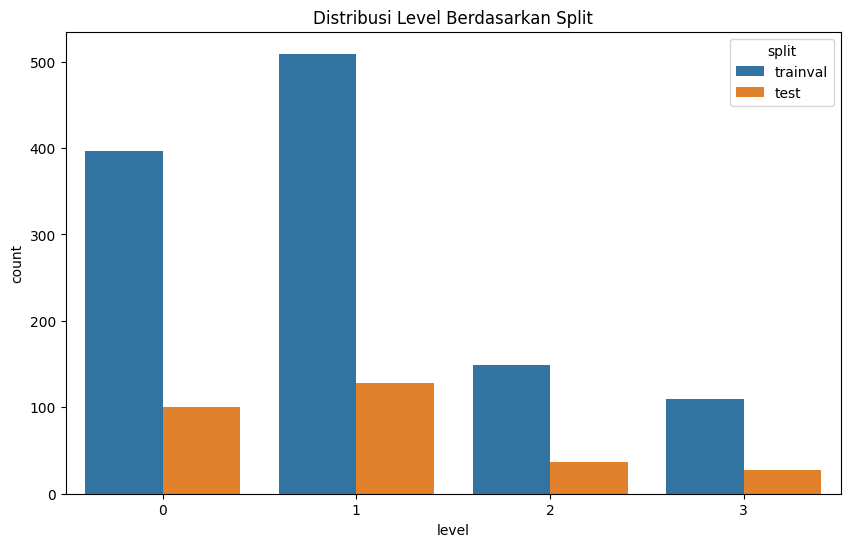

split,test,trainval
level,,
0,100,397
1,128,509
2,37,149
3,27,110


In [46]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="level",
    hue="split"
)

plt.title(
    "Distribusi Level Berdasarkan Split"
)

plt.show()

pd.crosstab(
    df["level"],
    df["split"]
)

**Insight**

Berdasarkan visualisasi distribusi level berdasarkan split, setiap level jerawat sudah muncul pada data `trainval` dan `test`. Pada level 0 terdapat **397 data trainval** dan **100 data test**, level 1 terdapat **509 data trainval** dan **128 data test**, level 2 terdapat **149 data trainval** dan **37 data test**, serta level 3 terdapat **110 data trainval** dan **27 data test**.
Hasil ini menunjukkan bahwa proses split ulang sudah menjaga keterwakilan setiap kelas pada data trainval dan test. Pembagian ini penting karena model perlu belajar dari semua level jerawat, dan data test juga harus memiliki sampel dari setiap level agar evaluasi dapat dilakukan secara lebih adil.



**7.5 Visualisasi Contoh Gambar per Level**


C:\Users\deaci\AppData\Local\Temp\ipykernel_23752\3848712532.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


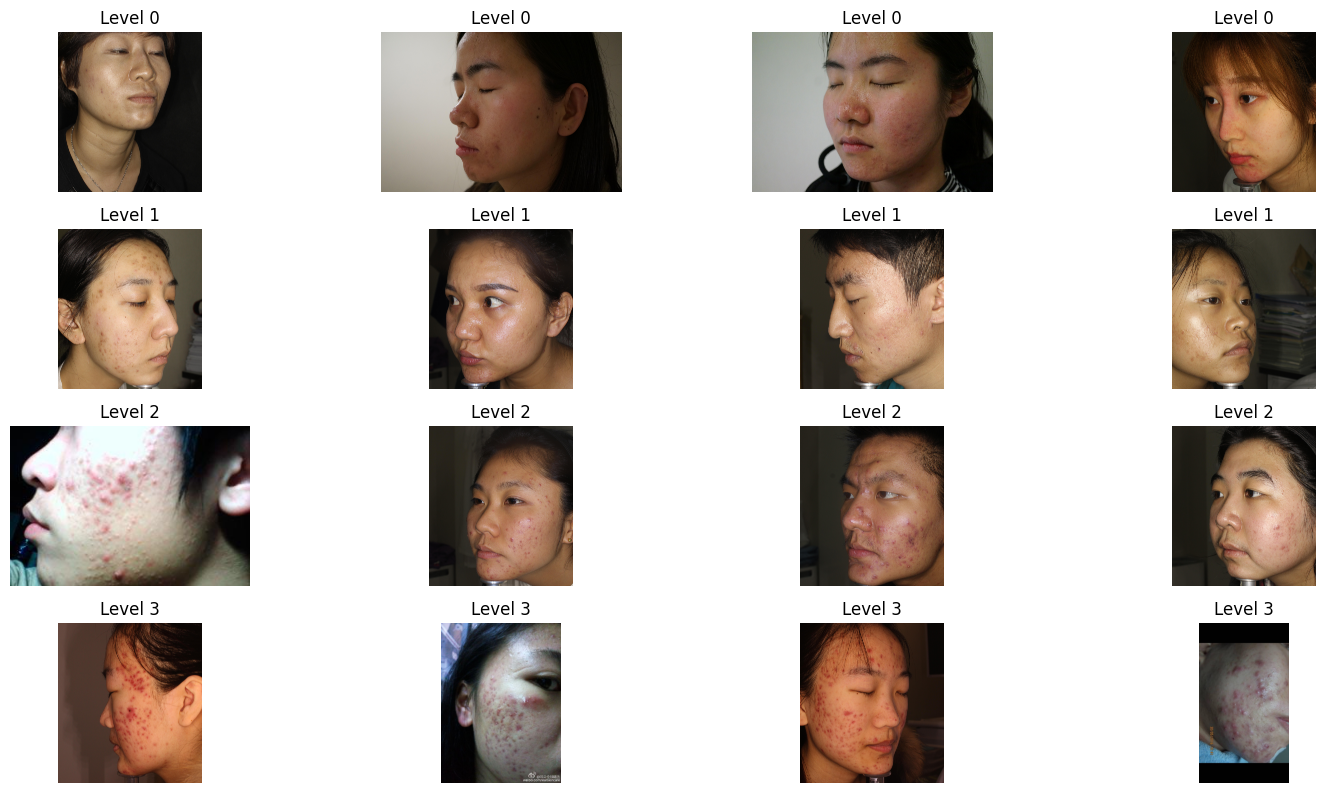

In [47]:
sample = (
    df
    .groupby("level")
    .apply(
        lambda x:
        x.sample(
            min(4,len(x)),
            random_state=42
        )
    )
)

plt.figure(
    figsize=(15,10)
)

for i,(_,row) in enumerate(sample.iterrows()):

    img = Image.open(
        row["filepath"]
    )

    plt.subplot(
        5,
        4,
        i+1
    )

    plt.imshow(img)

    plt.axis("off")

    plt.title(
        f"Level {row['level']}"
    )

plt.tight_layout()

plt.show()

**Insight**

Visualisasi sampel gambar per level menunjukkan contoh gambar dari masing-masing tingkat keparahan jerawat, mulai dari level 0 sampai level 3. Secara visual, level 0 terlihat memiliki kondisi kulit yang lebih ringan atau normal, sedangkan level 1 menunjukkan jerawat ringan. Pada level 2 dan level 3, tampak kondisi jerawat yang lebih banyak atau lebih terlihat jelas pada area wajah.

Visualisasi ini membantu memahami perbedaan karakteristik antar level secara langsung. Selain melihat data dalam bentuk angka, contoh gambar juga penting untuk memastikan bahwa label kelas memiliki gambaran visual yang masuk akal.


**7.6 Distribusi Ukuran Gambar**

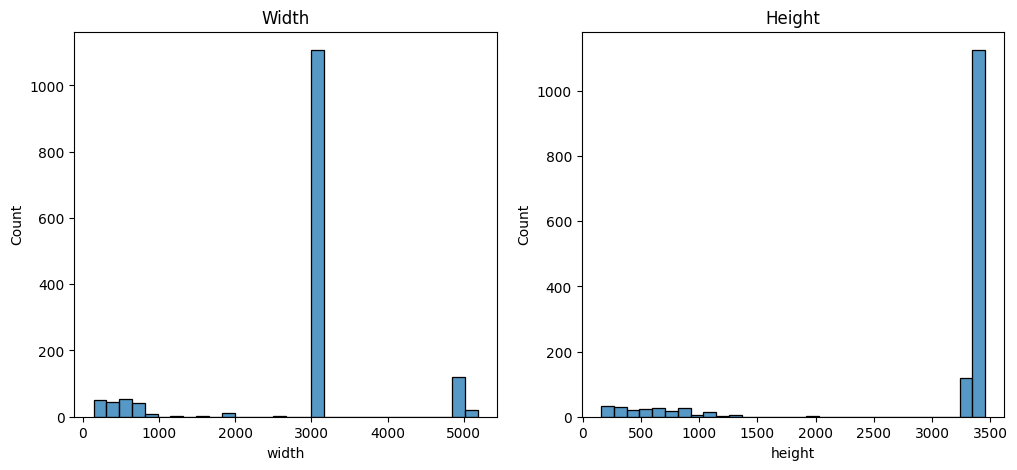

In [48]:
plt.figure(
    figsize=(12,5)
)

plt.subplot(1,2,1)

sns.histplot(
    df["width"],
    bins=30
)

plt.title("Width")

plt.subplot(1,2,2)

sns.histplot(
    df["height"],
    bins=30
)

plt.title("Height")

plt.show()

**Insight**

Berdasarkan histogram distribusi ukuran gambar, terlihat bahwa sebagian besar gambar memiliki ukuran yang relatif seragam, terutama pada ukuran sekitar **3112 × 3456 piksel**. Namun, masih terdapat beberapa gambar dengan ukuran yang lebih kecil maupun lebih besar, seperti gambar dengan lebar rendah di bawah 1000 piksel dan beberapa gambar dengan lebar sekitar 5000 piksel.Hal ini menunjukkan bahwa dataset memiliki variasi resolusi gambar. Variasi ukuran ini perlu diperhatikan karena model CNN membutuhkan input gambar dengan ukuran yang sama. Oleh karena itu, sebelum masuk ke tahap training, gambar perlu melalui proses resizing agar seluruh gambar memiliki dimensi yang seragam.


**7.7 Distribusi Aspect Rasio**

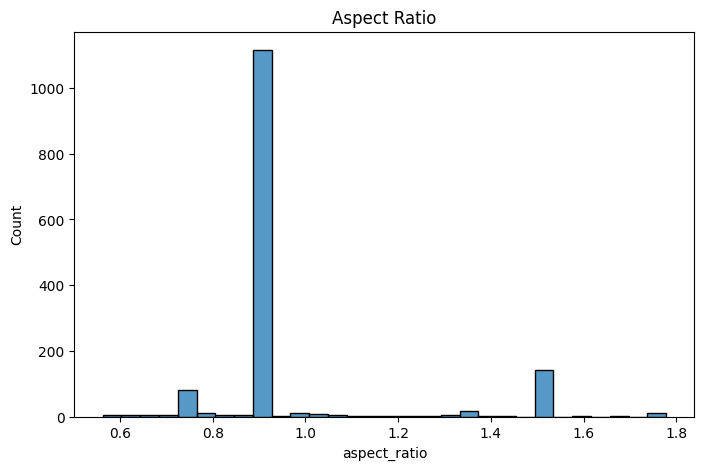

count    1457.000000
mean        0.966242
std         0.212318
min         0.562300
25%         0.900500
50%         0.900500
75%         0.900500
max         1.778400
Name: aspect_ratio, dtype: float64

In [49]:
plt.figure(
    figsize=(8,5)
)

sns.histplot(
    df["aspect_ratio"],
    bins=30
)

plt.title(
    "Aspect Ratio"
)

plt.show()

df["aspect_ratio"].describe()

**Insight**

Berdasarkan distribusi aspect ratio, sebagian besar gambar memiliki nilai aspect ratio sekitar **0,9005**. Nilai median dan kuartil juga berada pada angka yang sama, sehingga dapat disimpulkan bahwa mayoritas gambar memiliki rasio bentuk yang mirip.Namun, masih terdapat beberapa gambar dengan aspect ratio yang berbeda, mulai dari sekitar **0,56** hingga **1,78**. Hal ini menunjukkan bahwa ada sebagian gambar yang memiliki bentuk lebih portrait atau lebih landscape dibandingkan mayoritas gambar lainnya.

**7.8 Brightness Per Level**


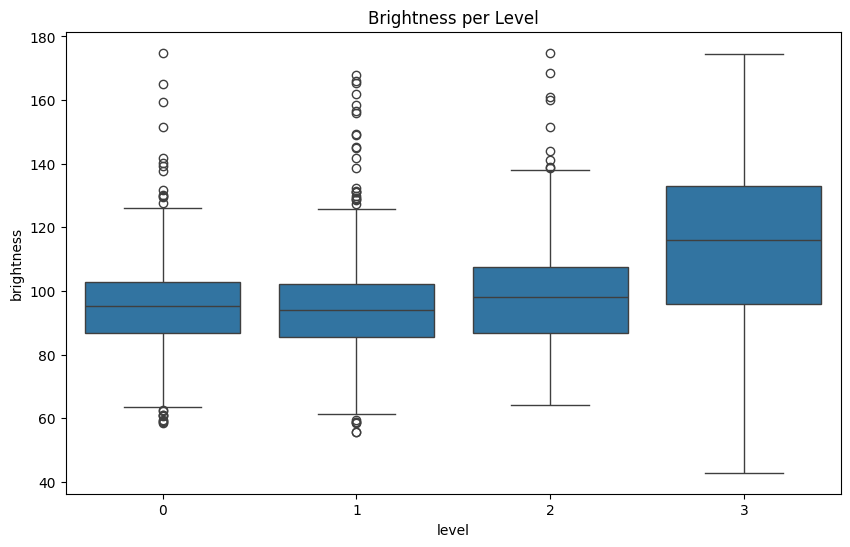

,count,mean,std,min,25%,50%,75%,max
level,,,,,,,,
0,497.0,95.312072,14.933874,58.45,86.840,95.28,102.7800,174.64
1,637.0,94.906295,15.913896,55.78,85.610,94.00,102.0800,167.77
2,186.0,100.371720,19.819482,64.09,86.965,98.10,107.4925,174.88
3,137.0,114.098029,24.472703,42.91,95.820,115.95,132.9500,174.42


In [52]:
plt.figure(
    figsize=(10,6)
)

sns.boxplot(
    data=df,
    x="level",
    y="brightness"
)

plt.title(
    "Brightness per Level"
)

plt.show()

(
df
.groupby(
"level"
)
["brightness"]
.describe()
)

**Insight**

Berdasarkan boxplot brightness per level, terlihat bahwa nilai brightness pada setiap level memiliki variasi. Level 0, level 1, dan level 2 memiliki median brightness yang relatif berdekatan, yaitu sekitar 94–98. Sementara itu, level 3 memiliki rata-rata dan median brightness yang lebih tinggi dibandingkan level lainnya, dengan mean sekitar **114,09**.
Hasil ini menunjukkan bahwa gambar pada level 3 cenderung memiliki tingkat kecerahan yang lebih tinggi. Namun, hal ini tidak boleh langsung disimpulkan bahwa tingkat kecerahan menentukan level jerawat. Perbedaan brightness bisa dipengaruhi oleh faktor lain seperti pencahayaan saat pengambilan foto, kualitas kamera, warna kulit, jarak foto, dan kondisi lingkungan.

In [51]:
eda_summary = df[
[
"width",
"height",
"file_size_kb",
"aspect_ratio",
"total_pixels",
"brightness",
"blur_score"
]
].describe()

eda_summary

,width,height,file_size_kb,aspect_ratio,total_pixels,brightness,blur_score
count,1457.000000,1457.000000,1457.000000,1457.000000,1.457000e+03,1457.000000,1457.000000
mean,2918.286205,3027.748799,756.628085,0.966242,9.782844e+06,97.547001,109.039472
std,1112.872289,1002.736785,328.447984,0.212318,4.179156e+06,18.000054,206.469484
min,143.000000,155.000000,3.250000,0.562300,2.431000e+04,42.910000,3.940000
25%,3112.000000,3456.000000,679.990000,0.900500,1.075507e+07,86.710000,38.350000
50%,3112.000000,3456.000000,855.490000,0.900500,1.075507e+07,95.560000,74.950000
75%,3112.000000,3456.000000,962.800000,0.900500,1.075507e+07,104.850000,113.740000
max,5184.000000,3456.000000,1353.240000,1.778400,1.791590e+07,174.880000,3963.120000


**Insight:**

Berdasarkan ringkasan statistik fitur gambar, jumlah data yang dianalisis adalah **1.457 sampel**, sesuai dengan jumlah data setelah cleaning. Hal ini menunjukkan bahwa EDA pada tahap ini sudah menggunakan dataset bersih, bukan data awal yang masih mengandung duplikasi.

Statistik menunjukkan bahwa rata-rata lebar gambar adalah sekitar **2918 piksel** dan rata-rata tinggi gambar sekitar **3028 piksel**. Namun, nilai minimum dan maksimum menunjukkan adanya variasi ukuran gambar yang cukup besar. Fitur `file_size_kb` juga bervariasi, mulai dari sekitar **3,25 KB** sampai **1353,24 KB**, yang menunjukkan perbedaan ukuran file antar gambar.

Fitur `brightness` memiliki rata-rata sekitar **97,55**, sedangkan `blur_score` memiliki variasi yang besar. Nilai blur score yang sangat rendah menunjukkan adanya gambar yang cenderung buram, sedangkan nilai yang sangat tinggi menunjukkan gambar yang lebih tajam. Informasi ini penting untuk memahami kualitas teknis dataset sebelum digunakan pada tahap pemodelan.

Secara umum, hasil EDA menunjukkan bahwa data sudah lebih bersih dari sisi duplikasi, tetapi masih memiliki tantangan berupa ketidakseimbangan kelas, variasi ukuran gambar, perbedaan aspect ratio, variasi pencahayaan, dan variasi ketajaman gambar.

# 8. Export Akhir

In [ ]:

# Membuat folder output
output_folder = "output"
os.makedirs(output_folder, exist_ok=True)

# Export semua metadata
df.to_csv(
    f"{output_folder}/metadata_acne_final.csv",
    index=False
)

# Export metadata trainval
df[df["split"] == "trainval"].to_csv(
    f"{output_folder}/trainval_metadata.csv",
    index=False
)

# Export metadata test
df[df["split"] == "test"].to_csv(
    f"{output_folder}/test_metadata.csv",
    index=False
)

print("Export selesai.")
print("File berhasil dibuat:")
print("- metadata_acne_final.csv")
print("- trainval_metadata.csv")
print("- test_metadata.csv")

Export selesai.
File berhasil dibuat:
- metadata_acne_final.csv
- trainval_metadata.csv
- test_metadata.csv


## Data Dictionary dan Ringkasan Dataset Final

Dataset ini merupakan metadata gambar jerawat yang telah melalui proses cleaning, validasi file, penghapusan duplikasi, pembagian ulang data train-test, dan feature engineering. Dataset final digunakan untuk analisis data, pelatihan model klasifikasi tingkat keparahan jerawat, serta validasi kualitas gambar.

### Ringkasan Dataset Setelah Preprocessing

| Informasi | Hasil |
|---|---:|
| Jumlah data awal | 5.828 |
| Jumlah data unik setelah cleaning | 1.457 |
| Jumlah data trainval final | 1.165 |
| Jumlah data test final | 292 |
| Jumlah gambar corrupt | 0 |
| Jumlah overlap trainval dan test | 0 |
| Jumlah level jerawat | 4 level |

### Distribusi Level Jerawat Setelah Cleaning

| Level | Jumlah Data | Keterangan |
|---|---:|---|
| 0 | 497 | Kulit normal atau jerawat sangat ringan |
| 1 | 637 | Jerawat ringan |
| 2 | 186 | Jerawat sedang |
| 3 | 137 | Jerawat berat |

### Distribusi Split Data

| Split Data | Jumlah Data |
|---|---:|
| trainval | 1.165 |
| test | 292 |

### Data Dictionary Dataset Klasifikasi Jerawat

| Nama Kolom | Tipe Data | Deskripsi |
|---|---|---|
| `filename` | String/Object | Nama file gambar jerawat yang digunakan sebagai identitas utama setiap gambar. |
| `filepath` | String/Object | Lokasi penyimpanan gambar pada folder dataset. |
| `level` | Integer | Label tingkat keparahan jerawat. Nilainya terdiri dari 0, 1, 2, dan 3. |
| `split` | String/Object | Pembagian data untuk kebutuhan model, yaitu `trainval` dan `test`. |
| `file_exists` | Boolean | Menunjukkan apakah file gambar tersedia pada path yang tercatat. Nilai `True` berarti file tersedia. |
| `is_corrupt` | Boolean | Menunjukkan apakah file gambar rusak atau tidak dapat dibuka. Nilai `False` berarti gambar tidak rusak. |
| `width` | Integer/Float | Lebar gambar dalam satuan pixel. |
| `height` | Integer/Float | Tinggi gambar dalam satuan pixel. |
| `channel` | Integer/Float | Jumlah channel warna pada gambar. Pada dataset ini umumnya bernilai 3 karena gambar menggunakan format RGB. |
| `file_size_kb` | Float | Ukuran file gambar dalam satuan kilobyte. |
| `aspect_ratio` | Float | Rasio perbandingan lebar dan tinggi gambar, dihitung dari `width / height`. |
| `total_pixels` | Integer/Float | Jumlah total pixel pada gambar, dihitung dari `width × height`. |
| `brightness` | Float | Nilai rata-rata kecerahan gambar setelah dikonversi ke grayscale. Kolom ini digunakan untuk melihat variasi pencahayaan gambar. |
| `blur_score` | Float | Nilai ketajaman gambar berdasarkan metode variance of Laplacian. Semakin kecil nilainya, semakin besar kemungkinan gambar blur. |

### Penjelasan Level Jerawat

| Level | Keterangan |
|---|---|
| 0 | Kulit normal atau jerawat sangat ringan |
| 1 | Jerawat ringan |
| 2 | Jerawat sedang |
| 3 | Jerawat berat |

### Kesimpulan

Berdasarkan hasil preprocessing, dataset klasifikasi jerawat telah dibersihkan dari potensi duplikasi dan overlap antara data trainval dan test. Dataset akhir terdiri dari 1.457 data unik dengan 4 kelas tingkat keparahan jerawat, yaitu level 0 sampai level 3. Metadata final juga dilengkapi dengan informasi kualitas gambar seperti ukuran gambar, brightness, dan blur score untuk mendukung proses analisis data dan pelatihan model.